<a href="https://colab.research.google.com/github/Kard00/Logica-programacao/blob/main/analise_vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importação das bibliotecas necessárias
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Conecta ao banco de dados. Se não existir, ele cria o arquivo dados_vendas.db
conexao = sqlite3.connect('dados_vendas.db')

# Cria um cursor para executar comandos SQL
cursor = conexao.cursor()

# Cria a tabela vendas1 caso ela não exista
cursor.execute('''
CREATE TABLE IF NOT EXISTS vendas1 (
    id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
    data_venda DATE,
    produto TEXT,
    categoria TEXT,
    valor_venda REAL
)
''')

# Insere os dados de vendas do último ano
cursor.execute('''
INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda) VALUES
('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
('2023-01-05', 'Produto B', 'Roupas', 350.00),
('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
('2023-03-15', 'Produto D', 'Livros', 200.00),
('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
('2023-04-02', 'Produto F', 'Roupas', 400.00),
('2023-05-05', 'Produto G', 'Livros', 150.00),
('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
('2023-07-20', 'Produto I', 'Roupas', 600.00),
('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
('2023-09-30', 'Produto K', 'Livros', 300.00),
('2023-10-05', 'Produto L', 'Roupas', 450.00),
('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
('2023-12-20', 'Produto N', 'Livros', 250.00);
''')

#  Confirma as mudanças no banco
conexao.commit()

#  Explorar e preparar os dados
# Carrega os dados da tabela SQL para um DataFrame do Pandas
df_vendas = pd.read_sql_query("SELECT * FROM vendas1", conexao)

#  Converte a coluna data_venda para o tipo datetime para facilitar análises por período
df_vendas['data_venda'] = pd.to_datetime(df_vendas['data_venda'])

#  Cria uma coluna de mês para agrupamentos mensais
df_vendas['mes'] = df_vendas['data_venda'].dt.month

print("=== Primeiras linhas do DataFrame ===")
print(df_vendas.head())
print("\n=== Informações gerais dos dados ===")
print(df_vendas.info())

#  Análise dos dados
# ===================
#  Total de vendas por categoria
vendas_por_categoria = df_vendas.groupby('categoria')['valor_venda'].sum().sort_values(ascending=False)
print("\n1. Total de vendas por categoria:")
print(vendas_por_categoria)

#  Produto com maior valor de venda
produto_maior_venda = df_vendas.loc[df_vendas['valor_venda'].idxmax()]
print("\n2. Produto com maior valor de venda:")
print(produto_maior_venda)

#  Média de valor de venda por mês
media_mensal = df_vendas.groupby('mes')['valor_venda'].mean()
print("\n3. Média de valor de venda por mês:")
print(media_mensal)

#  Visualização dos dados
# =======================
# Configura o estilo dos gráficos
sns.set(style="whitegrid")



=== Primeiras linhas do DataFrame ===
   id_venda data_venda    produto    categoria  valor_venda  mes
0         1 2023-01-01  Produto A  Eletrônicos       1500.0    1
1         2 2023-01-05  Produto B       Roupas        350.0    1
2         3 2023-02-10  Produto C  Eletrônicos       1200.0    2
3         4 2023-03-15  Produto D       Livros        200.0    3
4         5 2023-03-20  Produto E  Eletrônicos        800.0    3

=== Informações gerais dos dados ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venda     14 non-null     int64         
 1   data_venda   14 non-null     datetime64[ns]
 2   produto      14 non-null     object        
 3   categoria    14 non-null     object        
 4   valor_venda  14 non-null     float64       
 5   mes          14 non-null     int32         
dtypes: datetime64[ns](1), float64(1), i

/tmp/ipykernel_1383/2813529354.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vendas_por_categoria.index, y=vendas_por_categoria.values, palette="viridis")


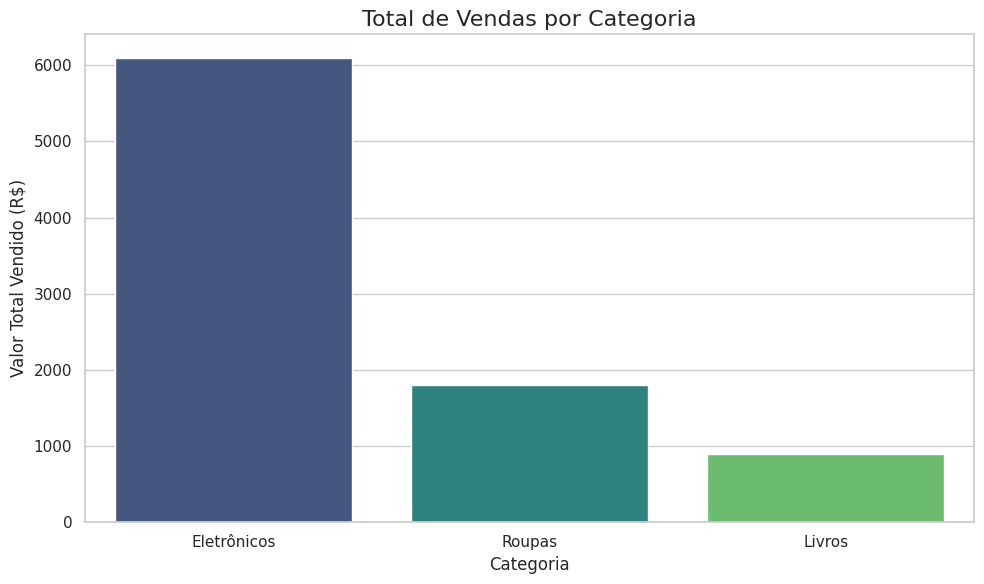

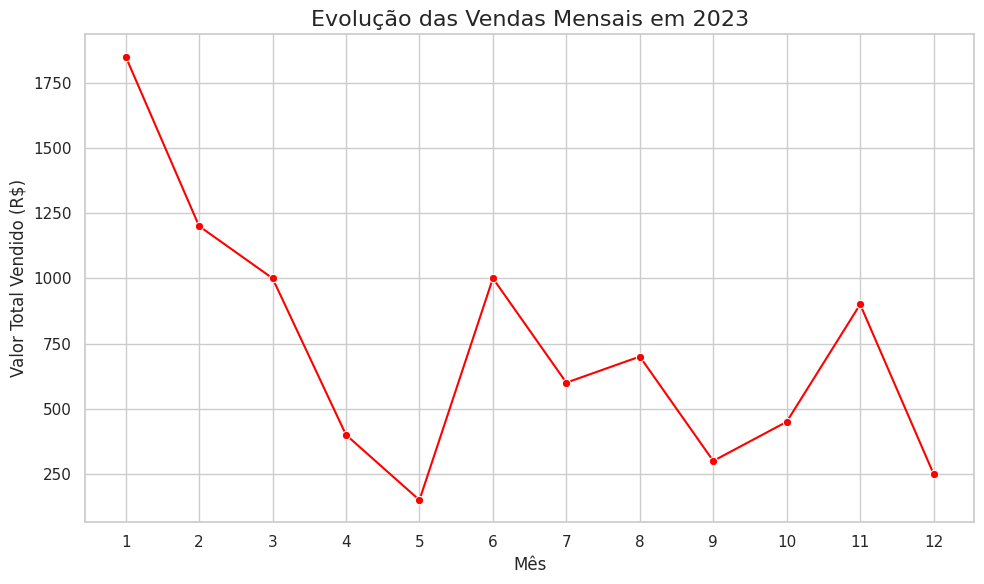

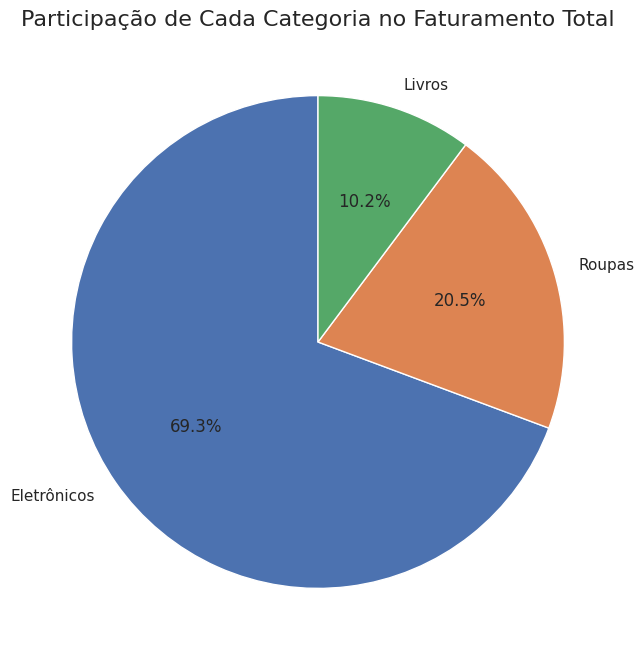

In [2]:
# Total de vendas por categoria
plt.figure(figsize=(10, 6))
sns.barplot(x=vendas_por_categoria.index, y=vendas_por_categoria.values, palette="viridis")
plt.title('Total de Vendas por Categoria', fontsize=16)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Valor Total Vendido (R$)', fontsize=12)
plt.tight_layout()
plt.show()

# Evolução das vendas ao longo dos meses
vendas_mensais = df_vendas.groupby('mes')['valor_venda'].sum()
plt.figure(figsize=(10, 6))
sns.lineplot(x=vendas_mensais.index, y=vendas_mensais.values, marker='o', color='red')
plt.title('Evolução das Vendas Mensais em 2023', fontsize=16)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Valor Total Vendido (R$)', fontsize=12)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

# Distribuição de vendas por categoria - Pizza
plt.figure(figsize=(8, 8))
plt.pie(vendas_por_categoria, labels=vendas_por_categoria.index, autopct='%1.1f%%', startangle=90)
plt.title('Participação de Cada Categoria no Faturamento Total', fontsize=16)
plt.show()

# Fecha a conexão com o banco
conexao.close()